# WaitCost - ML Pipeline, Model Training & Web-App Visuals

**The Cost of Doing Nothing** - USAII Global AI Hackathon 2026 - Graduate Track, Challenge 6 (Direction A)

This notebook walks the **entire pipeline**, stage by stage, then the backtest and the web-app visuals.
It imports the project's own modules (`model/`, `analysis/`, `agent/`) and calls the *same* functions the
app uses, so the notebook can never silently drift from the shipped engine. Runs fully offline on
`numpy`, `pandas`, `matplotlib`, `pyyaml`.

> *Run All* to regenerate everything. All numbers and charts below are produced by the code in this notebook.


## 0 - Pipeline at a glance

```
 data/coc_panel.csv  (HUD 2024 PIT  +  Census ACS 2024)
         |
         |  IM.load_panel()        -- INGEST: read CSV, derive homeless_rate_per_1k, log-transform skewed features
         v
   modelling frame  (17 CoCs x features + target)
         |
         |  IM._design()           -- TRANSFORM: select 4 features, z-score standardize (store mu, sd)
         v
   X  (standardized design matrix),  y = homeless_rate_per_1k
         |
         |  IM.select_model() + IM.leave_one_out()   -- TRAIN + SELECT: Ridge / GB-stump grid, pick best by leave-one-CoC-out CV
         v
   fitted model
         |--- IM.shap_values()     -- EXPLAIN: exact additive SHAP (which signal drove the prediction)
         |--- IM.calibrate_inflow()-- CALIBRATE: predicted rate -> monthly inflow + learned uncertainty band
         v
   model/inflow_model.json   (IM.save_report)        -- ARTIFACT
         |
         |  skills.load_inflow_model() + config/params.yaml (skills.fetch_hud_data)
         v
   model.simulate() + model.run_montecarlo()         -- SIMULATOR: 10-yr cost trajectories with P10-P90 bands
         |
         v
   FastAPI ( /scenario /ask /model /chart /backtest ) -> analyst + viz + city-brief agents -> web app
```

Sources for every input: `data_sources/SOURCES_MANIFEST.md`.


In [1]:
import os, sys, json, inspect, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def find_repo():
    for cand in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (cand/"config"/"params.yaml").exists() and (cand/"model"/"inflow_model.py").exists():
            return cand
    raise RuntimeError("Run this notebook from inside the WaitCost repo.")
REPO = find_repo(); os.chdir(REPO); sys.path.insert(0, str(REPO))

from model import inflow_model as IM
from model import backtest as BT
from model import simulate as SIM, montecarlo as MC
from analysis import viz
from agent import skills
print("repo:", REPO)
print("model features:", IM.FEATURES)

repo: /sessions/laughing-blissful-cerf/mnt/Build AI-System/inactioncost
model features: ['log_median_home_value', 'poverty_rate', 'median_household_income', 'log_pop_density']


## 1 - INGEST  (`IM.load_panel`)

Read the real 17-CoC CSV (HUD PIT + Census ACS), derive the modelling target `homeless_rate_per_1k`,
and log-transform the two right-skewed features (home value, density). No synthetic rows.


In [2]:
print(inspect.getsource(IM.load_panel))
df = IM.load_panel("data/coc_panel.csv")
print("ingested frame:", df.shape, "\nderived/added columns shown below:")
df[["coc","pit_total","population","homeless_rate_per_1k",
    "median_home_value","log_median_home_value","pop_density_sqmi","log_pop_density"]].round(3).head(6)

def load_panel(csv_path):
    """Load the real CoC panel and derive the modelling frame."""
    df = pd.read_csv(csv_path)
    df["homeless_rate_per_1k"] = df["pit_total"] / df["population"] * 1000.0
    df["unsheltered_rate_per_1k"] = df["pit_unsheltered"] / df["population"] * 1000.0
    df["log_median_home_value"] = np.log(df["median_home_value"].astype(float))
    df["log_pop_density"] = np.log(df["pop_density_sqmi"].astype(float))
    return df

ingested frame: (17, 20) 
derived/added columns shown below:


## 2 - TRANSFORM  (`IM._design`)

Select the four economically-motivated, low-collinearity features and **z-score standardize** them
(so Ridge shrinkage and SHAP are on a common scale). The mean/SD used for standardization are kept.


In [3]:
print(inspect.getsource(IM._design))
Xs, mu, sd = IM._design(df)
y = df["homeless_rate_per_1k"].to_numpy(float)
print("design matrix X:", Xs.shape, " target y:", y.shape)
print("\nstandardization stats per feature:")
for f, m, s in zip(IM.FEATURES, mu, sd):
    print(f"  {f:26s} mean={m:12.3f}  sd={s:12.3f}")
pd.DataFrame(Xs, columns=IM.FEATURES, index=df["coc"]).round(2).head(6)

def _design(df):
    X = df[FEATURES].to_numpy(float)
    mu = X.mean(axis=0)
    sd = X.std(axis=0)
    sd[sd == 0] = 1.0
    Xs = (X - mu) / sd
    return Xs, mu, sd

design matrix X: (17, 4)  target y: (17,)

standardization stats per feature:
  log_median_home_value      mean=      13.293  sd=       0.484
  poverty_rate               mean=      12.876  sd=       3.364
  median_household_income    mean=   96272.824  sd=   26137.916
  log_pop_density            mean=       7.677  sd=       1.465


## 3 - TRAIN + SELECT  (`IM.select_model` via `IM.leave_one_out`)

Candidates = Ridge over an alpha grid + gradient-boosted stumps over a rounds grid. We pick the one with
the best **leave-one-CoC-out** R² (train on 16 cities, test on the held-out 17th, rotate). Honest because
*n* is small and we never score a city the model trained on.


In [4]:
# reconstruct the exact candidate grid select_model() searches, and rank it
candidates = [(f"ridge(alpha={a})", (lambda a=a: IM.RidgeLinear(alpha=a))) for a in (0.3,1.0,3.0,10.0,30.0)]
candidates += [(f"gb_stumps(rounds={m})", (lambda m=m: IM.GBStumps(n_rounds=m, lr=0.1, min_leaf=3))) for m in (10,20,30,40,50)]
ranked = sorted(((lab, IM.leave_one_out(Xs, y, fac)) for lab, fac in candidates),
                key=lambda t: t[1]["loo_r2"], reverse=True)
print(f"{'candidate':22s} {'LOO R2':>8s} {'LOO MAE':>9s}")
for lab, r in ranked:
    print(f"  {lab:20s} {r['loo_r2']:8.3f} {r['loo_mae']:9.3f}")

label, factory, loo = IM.select_model(Xs, y)     # the shipped selector
model = factory().fit(Xs, y)
print(f"\nWINNER: {label}   LOO R2={loo['loo_r2']:.3f}  LOO MAE={loo['loo_mae']:.2f}")

candidate                LOO R2   LOO MAE
  gb_stumps(rounds=50)    0.361     1.924
  ridge(alpha=1.0)        0.355     2.257
  ridge(alpha=3.0)        0.351     2.221
  gb_stumps(rounds=40)    0.345     1.975
  ridge(alpha=0.3)        0.345     2.341
  gb_stumps(rounds=30)    0.335     2.057
  ridge(alpha=10.0)       0.307     2.247
  gb_stumps(rounds=20)    0.291     2.239
  ridge(alpha=30.0)       0.188     2.623
  gb_stumps(rounds=10)    0.180     2.677

WINNER: gb_stumps(rounds=50)   LOO R2=0.361  LOO MAE=1.92


## 4 - EVALUATE

Held-out predictions vs. observed rate, city by city. Points near the 45° line = good generalization.


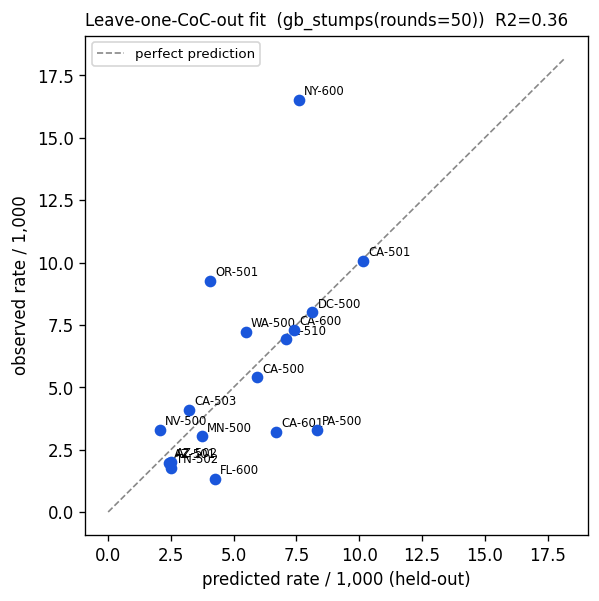

In [5]:
loo_pred = np.array(loo["loo_pred"])
fig, ax = plt.subplots(figsize=(5.4,5.4))
ax.scatter(loo_pred, y, color="#1A56DB", zorder=5)
lim = [0, max(y.max(), loo_pred.max())*1.1]
ax.plot(lim, lim, ls="--", color="#888", lw=1, label="perfect prediction")
for i, coc in enumerate(df["coc"]):
    ax.annotate(coc, (loo_pred[i], y[i]), fontsize=7, xytext=(3,3), textcoords="offset points")
ax.set_xlabel("predicted rate / 1,000 (held-out)"); ax.set_ylabel("observed rate / 1,000")
ax.set_title(f"Leave-one-CoC-out fit  ({label})  R2={loo['loo_r2']:.2f}", fontsize=10, loc="left")
ax.legend(fontsize=8); plt.show()

## 5 - EXPLAIN  (`IM.shap_values`)

Exact additive SHAP for the target city (CA-600): each feature's signed push on the predicted rate.
Housing cost dominates - consistent with the literature.


def shap_values(model, X, Xref):
    """EXACT Shapley values for the additive model.

    φ_j(x) = g_j(x_j) − E_train[g_j].  Sums to f(x) − E_train[f].  For an
    additive model these equal what shap.TreeExplainer would return.
    """
    G = model._feature_contrib_matrix(X)
    Gref_mean = model._feature_contrib_matrix(Xref).mean(axis=0)
    return G - Gref_mean   # (n, p)

  log_median_home_value      +2.331
  log_pop_density            -0.292
  poverty_rate               -0.163
  median_household_income    +0.000


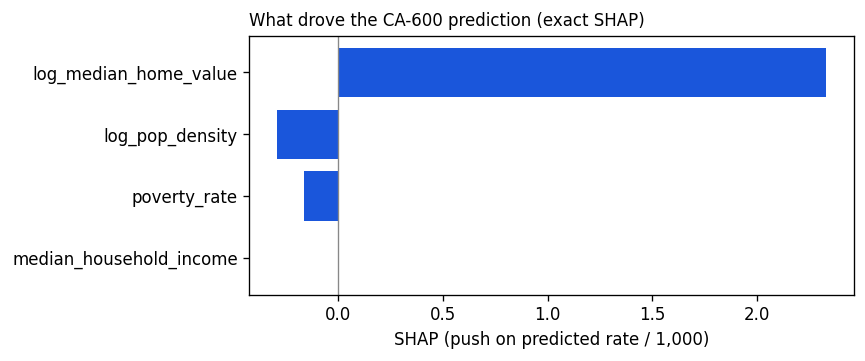

In [6]:
print(inspect.getsource(IM.shap_values))
ti = int(df.index[df["coc"]=="CA-600"][0])
sv = IM.shap_values(model, Xs[ti:ti+1], Xs)[0]
order = np.argsort(np.abs(sv))
fig, ax = plt.subplots(figsize=(6.5,2.8))
ax.barh([IM.FEATURES[i] for i in order], [sv[i] for i in order], color="#1A56DB")
ax.axvline(0, color="#888", lw=.8); ax.set_xlabel("SHAP (push on predicted rate / 1,000)")
ax.set_title("What drove the CA-600 prediction (exact SHAP)", fontsize=10, loc="left"); plt.show()
for i in reversed(order):
    print(f"  {IM.FEATURES[i]:26s} {sv[i]:+.3f}")

## 6 - CALIBRATE  (`IM.calibrate_inflow`)

Turn the predicted prevalence rate (+ its learned P10-P90 band) into the simulator's **monthly at-risk
inflow** - the number of new people entering homelessness per month, with a model-derived uncertainty
the Monte Carlo will propagate.


In [7]:
print(inspect.getsource(IM.calibrate_inflow))
report = IM.train_and_calibrate("data/coc_panel.csv")     # the full orchestrator (stages 1-6)
imo = report["inflow_at_risk_monthly"]
print("CALIBRATED INFLOW (CA-600):")
print(f"  predicted rate /1k : {report['predicted_rate_per_1k']:.2f}  (P10-P90 {report['pred_rate_p10']:.2f}-{report['pred_rate_p90']:.2f})")
print(f"  monthly inflow P50 : {imo['p50']:.0f}/mo   band {imo['p10']:.0f}-{imo['p90']:.0f}   implied CV {imo['implied_cv']:.2f}")
print(f"  annual turnover    : {imo['annual_turnover']}")

def calibrate_inflow(pred_rate_per_1k, lo_rate, hi_rate, population,
                     annual_turnover=0.35, at_risk_share=1.0):
    """Convert a predicted homeless prevalence rate into a monthly at-risk inflow.

    Transparent flow assumption (documented, tagged low-confidence pending HUD
    SPM Measure-5 'first-time homeless' calibration): each year roughly
    `annual_turnover` of the homeless stock is replaced by new entries, so

        annual_new_entries ≈ prevalence_count × annual_turnover
        monthly_inflow_at_risk ≈ annual_new_entries / 12

    The band (p10/p90) is carried straight from the model's prediction interval
    so the Monte Carlo propagates a *learned* uncertainty, not a hand-set one.
    """
    def to_monthly(rate):
        count = rate / 1000.0 * population
        return count * annual_turnover / 12.0 * at_risk_share

    p50 = to_monthly(pred_rate_per_1k)
    p10 = to_monthly(lo_rate)
    p90 = to_monthly(hi_rate)
    # coefficient of variation implie

## 7 - PERSIST  (`IM.save_report`)

Write the model card to JSON. The shipped artifact is `model/inflow_model.json`; the simulator loads it
via `skills.load_inflow_model()`. (Here we write a side copy so we don't clobber the shipped file.)


In [8]:
out = IM.save_report(report, "notebooks/inflow_model.run.json")
print("wrote", out)
print(json.dumps({k: report[k] for k in ["target_coc","model","loo_r2","loo_mae","predicted_rate_per_1k"]}, indent=2))

wrote notebooks/inflow_model.run.json
{
  "target_coc": "CA-600",
  "model": "gb_stumps(rounds=50)",
  "loo_r2": 0.36116483485899864,
  "loo_mae": 1.9237294994174388,
  "predicted_rate_per_1k": 7.4491919797718955
}


## 8 - SERVE INTO THE SIMULATOR

The calibrated inflow (baked into `config/params.yaml`) feeds the system-dynamics simulator
(`model.simulate`) which Monte-Carlo runs (`model.montecarlo`) to produce 10-year cost trajectories with
P10-P90 bands. The face-validity **backtest** seeds the real 2023 counts and checks the predicted 2024
band contains the observed count.


BACKTEST (CA-600, seed 2023 -> predict 2024)
  predicted 2024 (P50): 68497   band 65006-72536
  observed 2024 (HUD) : 71,201   abs error 3.8%   inside band: True


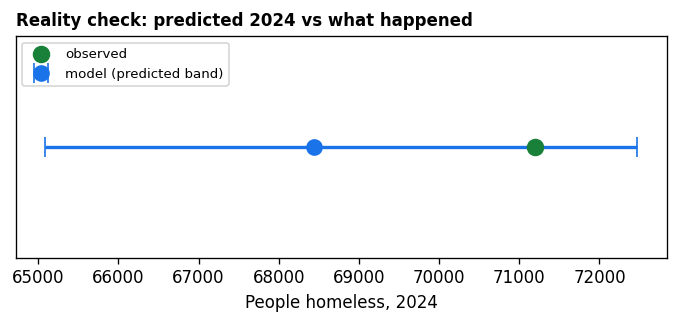

In [9]:
params = skills.fetch_hud_data("config/params.yaml")
bt = BT.backtest(params)
print("BACKTEST (CA-600, seed 2023 -> predict 2024)")
print(f"  predicted 2024 (P50): {bt['predicted_active_p50']:.0f}   band {bt['predicted_active_p10']:.0f}-{bt['predicted_active_p90']:.0f}")
print(f"  observed 2024 (HUD) : {bt['observed_2024_total']:,}   abs error {bt['abs_pct_error_p50']:.1f}%   inside band: {bt['within_band']}")

spec = viz.build_chart("backtest")
fig, ax = plt.subplots(figsize=(7,2.4))
for s in spec["series"]:
    if "y_lo" in s:
        ax.errorbar(s["y"], [0], xerr=[[s["y"][0]-s["y_lo"][0]],[s["y_hi"][0]-s["y"][0]]],
                    fmt="o", ms=9, color=s.get("color","#1A56DB"), capsize=6, lw=2, label=s["name"]+" (predicted band)")
    else:
        ax.scatter(s["y"], [0], s=90, color=s.get("color","#188038"), zorder=5, label=s["name"])
ax.set_yticks([]); ax.set_xlabel("People homeless, 2024"); ax.legend(loc="upper left", fontsize=8)
ax.set_title(spec["title"], loc="left", fontsize=10, weight="bold"); plt.show()

## 9 - The web-app visuals

The React app hard-codes no chart: the visualization agent builds a **framework-agnostic chart spec**
(`analysis/viz.build_chart`) from real engine output, and the frontend renders it. Below are the same
specs drawn with matplotlib - identical numbers, same source of truth.


example spec keys: ['name', 'kind', 'title', 'subtitle', 'x_label', 'y_label', 'series', 'caption', 'source', 'how_to_read']
title : Extra cost of waiting vs acting now, over 10 years
source: Computed from the WaitCost engine (real HUD PIT + Census ACS).


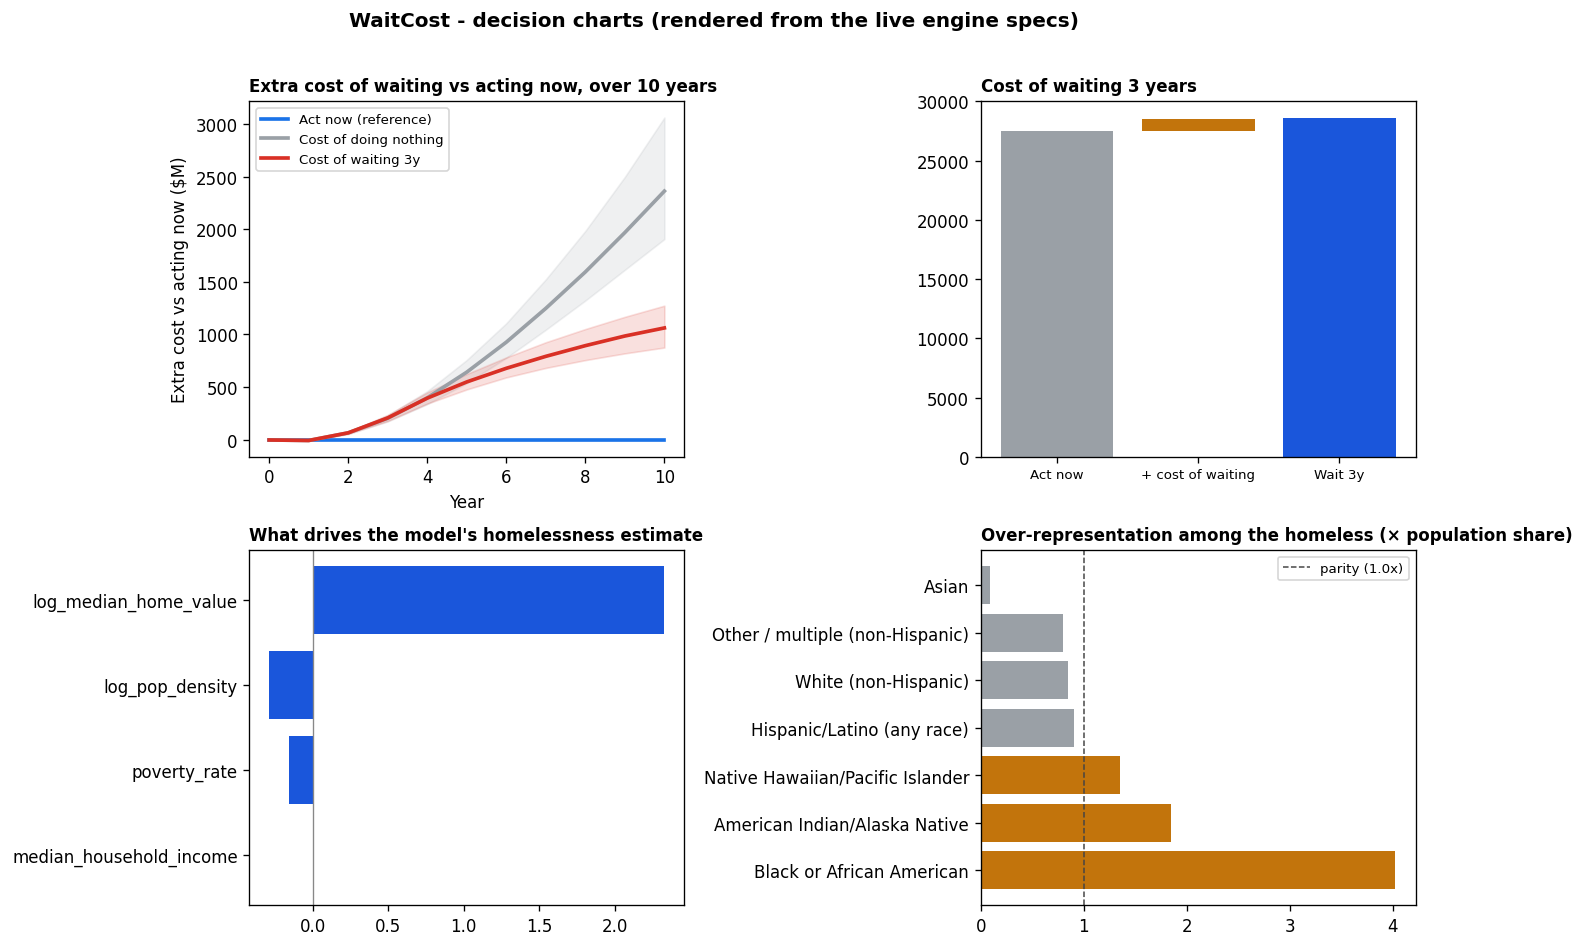

In [10]:
spec = viz.build_chart("cost_trajectory")
print("example spec keys:", list(spec))
print("title :", spec["title"]); print("source:", spec["source"])

def r_line_band(spec, ax):
    for s in spec["series"]:
        ax.plot(s["x"], s["y"], color=s.get("color"), lw=2.2, label=s["name"])
        if "y_lo" in s: ax.fill_between(s["x"], s["y_lo"], s["y_hi"], color=s.get("color"), alpha=.15)
    ax.legend(fontsize=8); ax.set_xlabel(spec.get("x_label","")); ax.set_ylabel(spec.get("y_label",""))
def r_shap(spec, ax):
    d=spec["series"][0]; ax.barh(d["y"], d["x"], color="#1A56DB"); ax.invert_yaxis(); ax.axvline(0,color="#888",lw=.8)
def r_hbar(spec, ax):
    d=spec["series"][0]; cols=["#C2740C" if h else "#9aa0a6" for h in d.get("highlight",[False]*len(d["x"]))]
    ax.barh(d["y"], d["x"], color=cols); ax.invert_yaxis()
    if "disparit" in spec["name"]: ax.axvline(1.0,color="#444",ls="--",lw=.9,label="parity (1.0x)"); ax.legend(fontsize=8)
def r_waterfall(spec, ax):
    d=spec["series"][0]
    for i,(val,base,meas) in enumerate(zip(d["y"], d.get("base",[0]*len(d["x"])), d.get("measure",[]))):
        col="#9aa0a6" if meas=="absolute" else ("#C2740C" if meas=="relative" else "#1A56DB"); ax.bar(i,val,bottom=base,color=col)
    ax.set_xticks(range(len(d["x"]))); ax.set_xticklabels(d["x"], fontsize=8)
RENDER={"line_band":r_line_band,"shap_bar":r_shap,"bar":r_hbar,"waterfall":r_waterfall}

charts=["cost_trajectory","cost_of_waiting","shap_drivers","equity_disparity"]
fig, axes = plt.subplots(2,2,figsize=(12,8))
for name, ax in zip(charts, axes.ravel()):
    s = viz.build_chart(name)
    RENDER.get(s["kind"], lambda s,a: a.text(.5,.5,"(unsupported)",ha="center"))(s, ax)
    ax.set_title(s["title"], loc="left", fontsize=10, weight="bold")
fig.suptitle("WaitCost - decision charts (rendered from the live engine specs)", fontsize=12, weight="bold")
fig.tight_layout(rect=[0,0,1,0.97]); plt.show()

## 10 - Reproducibility & honesty

- Every number and figure is produced by **this notebook**, importing the project's own modules - the
  same code the web app, the CLI, and the API use, so they cannot disagree.
- The pipeline is fully visible above: ingest -> transform -> train+select (held-out CV) -> explain ->
  calibrate -> persist -> simulate.
- The model is **deliberately modest** (held-out R2 ~ 0.36) and reported honestly; the backtest shows the
  observed 2024 count inside the predicted band (~4% error).
- Calibrated for **CA-600 (Los Angeles)**; the same trained model scores the other 16 cities (flow/cost
  priors are CA-600 until locally calibrated). All outputs are **ranges**, not fake-precise points.
- Full provenance: `data_sources/SOURCES_MANIFEST.md`.
